In [1]:
import pandas as pd
import numpy as np


def add_delta_columns(df: pd.DataFrame, methods=None) -> pd.DataFrame:
    """
    Add per-method delta columns:
    Delta = Unseen - Seen
    DeltaRatio currently mirrors Delta as in the original notebook logic.
    """
    if methods is None:
        methods = ["cade", "chen", "enidrift", "pe", "lmt"]

    df = df.copy()

    for m in methods:
        benign_col = f"{m}_score_benign"
        seen_col = f"{m}_score_seen_mean"
        unseen_col = f"{m}_score_unseen"
        delta_col = f"{m}_delta"
        deltaratio_col = f"{m}_deltaratio"

        if seen_col in df.columns and unseen_col in df.columns:
            df[delta_col] = df[unseen_col] - df[seen_col]
            df[deltaratio_col] = df[delta_col]
        else:
            df[delta_col] = np.nan
            df[deltaratio_col] = np.nan

    return df


def make_stage_label(row: pd.Series) -> str:
    """
    Convert seen_classes into a readable stage label.
    Example:
    'Benign | HTTP Flood | OS Scan' -> 'S2 = Benign + Attack(1..2)'
    """
    classes = [x.strip() for x in str(row["seen_classes"]).split("|")]
    if len(classes) <= 1:
        return "Baseline"

    attacks = [c for c in classes if c != "Benign"]
    if len(attacks) == 0:
        return "Baseline"

    return f"S{len(attacks)} = Benign + Attack(1..{len(attacks)})"


def add_stage_labels(df: pd.DataFrame) -> pd.DataFrame:
    """
    Add stage_label column.
    """
    df = df.copy()
    df["stage_label"] = df.apply(make_stage_label, axis=1)
    return df


def build_table_long(df: pd.DataFrame, methods=None, round_digits=2) -> pd.DataFrame:
    """
    Transform the wide experiment CSV into the long-format summary table.
    """
    if methods is None:
        methods = ["cade", "chen", "enidrift", "pe", "lmt"]

    rows = []

    for _, r in df.iterrows():
        for m in methods:
            rows.append({
                "Stage": r["stage_label"],
                "Stage_ID": r["stage_id"],
                "Probe": r["probe_class"],
                "Drift Method": m.upper(),
                "Acc": r["accuracy"],
                "F1": r["f1_macro"],
                "Benign": r.get(f"{m}_score_benign", np.nan),
                "Seen": r.get(f"{m}_score_seen_mean", np.nan),
                "Unseen": r.get(f"{m}_score_unseen", np.nan),
                "Delta": r.get(f"{m}_delta", np.nan),
            })

    table_long = pd.DataFrame(rows)

    num_cols = ["Acc", "F1", "Benign", "Seen", "Unseen", "Delta"]
    for col in num_cols:
        if col in table_long.columns:
            table_long[col] = table_long[col].round(round_digits)

    return table_long


def load_progressive_results(csv_path: str, methods=None, round_digits=2):
    """
    Full pipeline:
    1. load csv
    2. add delta columns
    3. add stage labels
    4. build long table

    Returns:
        df_raw, table_long
    """
    if methods is None:
        methods = ["cade", "chen", "enidrift", "pe", "lmt"]

    df = pd.read_csv(csv_path)
    df = add_delta_columns(df, methods=methods)
    df = add_stage_labels(df)
    table_long = build_table_long(df, methods=methods, round_digits=round_digits)

    return df, table_long

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def plot_conditional_subplots(
    table_long: pd.DataFrame,
    save_path="ciciot23.pdf",
    method_order=None,
    figsize_per_plot=(5, 6),
    font_main=30,
    font_extra=28,
    show=True,
):
    """
    Plot 1 x N subplot of conditional drift scores (Benign, Seen, Unseen).

    Parameters
    ----------
    table_long : pd.DataFrame
        Must contain columns:
        Stage, Stage_ID, Probe, Drift Method, Benign, Seen, Unseen

    save_path : str
        Output figure path

    method_order : list or None
        Order of methods to display

    figsize_per_plot : tuple
        Size per subplot (width, height)

    font_main : int
        Main font size

    show : bool
        Whether to display the plot
    """

    # ---------------------------------------------------------
    # Style
    # ---------------------------------------------------------
    COLORS = {
        "dark_blue": "#34669A",
        "orange": "#E0795F",
        "red": "#B00A0B",
    }

    plt.rcParams["font.size"] = font_main
    plt.rcParams["axes.labelsize"] = font_main
    plt.rcParams["xtick.labelsize"] = font_main
    plt.rcParams["ytick.labelsize"] = font_main
    plt.rcParams["legend.fontsize"] = font_main

    # ---------------------------------------------------------
    # Clean data
    # ---------------------------------------------------------
    dfp = table_long.copy()

    dfp = dfp[dfp["Probe"].astype(str) != "None"].copy()
    dfp["Drift Method"] = dfp["Drift Method"].astype(str).str.upper()
    dfp = dfp.dropna(subset=["Benign", "Seen", "Unseen"])

    # method order
    if method_order is None:
        method_order = ["CADE", "CHEN", "ENIDRIFT", "PE", "LMT"]

    method_order = [m for m in method_order if m in dfp["Drift Method"].unique()]

    # stage order
    stage_order = (
        dfp[["Stage_ID", "Stage"]]
        .drop_duplicates()
        .sort_values("Stage_ID")
    )

    stage_ids = stage_order["Stage_ID"].tolist()

    # ---------------------------------------------------------
    # Plot
    # ---------------------------------------------------------
    n_methods = len(method_order)
    fig_w = figsize_per_plot[0] * n_methods
    fig_h = figsize_per_plot[1]

    fig, axes = plt.subplots(1, n_methods, figsize=(fig_w, fig_h), sharex=True)

    if n_methods == 1:
        axes = [axes]

    for ax, method in zip(axes, method_order):
        sub = dfp[dfp["Drift Method"] == method].copy()
        sub = sub.sort_values("Stage_ID")

        sub = (
            pd.DataFrame({"Stage_ID": stage_ids})
            .merge(sub, on="Stage_ID", how="left")
        )

        x = np.arange(len(stage_ids))

        ax.plot(
            x, sub["Benign"].values,
            marker="o", linewidth=3, markersize=10,
            color=COLORS["dark_blue"], label="Benign"
        )
        ax.plot(
            x, sub["Seen"].values,
            marker="s", linewidth=3, markersize=10,
            color=COLORS["orange"], label="Seen"
        )
        ax.plot(
            x, sub["Unseen"].values,
            marker="^", linewidth=3, markersize=12,
            color=COLORS["red"], label="Unseen"
        )

        ax.set_title(method, fontsize=font_main)
        ax.set_xticks(x)
        ax.set_xticklabels([f"S{i+1}" for i in range(len(stage_ids))])
        ax.grid(alpha=0.25)

        if ax is axes[0]:
            ax.set_ylabel("Drift Score", fontsize=font_main)

    # shared legend
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=3, frameon=False)

    fig.supxlabel("Stage", fontsize=font_main, y=0.2)

    plt.tight_layout(rect=[0, 0.08, 1, 0.90])
    plt.savefig(save_path, dpi=300, bbox_inches="tight")

    if show:
        plt.show()
    else:
        plt.close()

    return stage_order.reset_index(drop=True)

### Generate the Table

In [4]:
csv_path = "../data/public_datasets/res_android_mal/public_progressive_cae.csv"
methods = ["cade", "chen", "enidrift", "pe", "lmt"]

df, table_long = load_progressive_results(
    csv_path=csv_path,
    methods=methods,
    round_digits=2,
)

print(df[["stage_id", "seen_classes", "stage_label", "probe_class"]].head())
table_long.head(20)

   stage_id                                       seen_classes  \
0         1                                    benign | dowgin   
1         2                          benign | dowgin | fakeapp   
2         3           benign | dowgin | fakeapp | simplelocker   
3         4  benign | dowgin | fakeapp | simplelocker | pla...   
4         5  benign | dowgin | fakeapp | simplelocker | pla...   

                  stage_label   probe_class  
0  S2 = Benign + Attack(1..2)       fakeapp  
1  S3 = Benign + Attack(1..3)  simplelocker  
2  S4 = Benign + Attack(1..4)      plankton  
3  S5 = Benign + Attack(1..5)        svpeng  
4  S6 = Benign + Attack(1..6)         youmi  


,Stage,Stage_ID,Probe,Drift Method,Acc,F1,Benign,Seen,Unseen,Delta
0,S2 = Benign + Attack(1..2),1,fakeapp,CADE,0.61,0.46,0.63,0.71,0.84,0.12
1,S2 = Benign + Attack(1..2),1,fakeapp,CHEN,0.61,0.46,1.75,1.74,1.71,-0.03
2,S2 = Benign + Attack(1..2),1,fakeapp,ENIDRIFT,0.61,0.46,0.22,0.22,0.21,-0.00
3,S2 = Benign + Attack(1..2),1,fakeapp,PE,0.61,0.46,0.39,0.46,0.54,0.09
4,S2 = Benign + Attack(1..2),1,fakeapp,LMT,0.61,0.46,35.16,39.04,52.48,13.44
5,S3 = Benign + Attack(1..3),2,simplelocker,CADE,0.50,0.41,0.72,0.62,0.78,0.17
6,S3 = Benign + Attack(1..3),2,simplelocker,CHEN,0.50,0.41,1.79,1.78,1.64,-0.14
7,S3 = Benign + Attack(1..3),2,simplelocker,ENIDRIFT,0.50,0.41,0.24,0.22,0.22,-0.01
8,S3 = Benign + Attack(1..3),2,simplelocker,PE,0.50,0.41,0.57,0.77,0.89,0.11
9,S3 = Benign + Attack(1..3),2,simplelocker,LMT,0.50,0.41,33.43,36.22,43.46,7.24


### Generate the figure

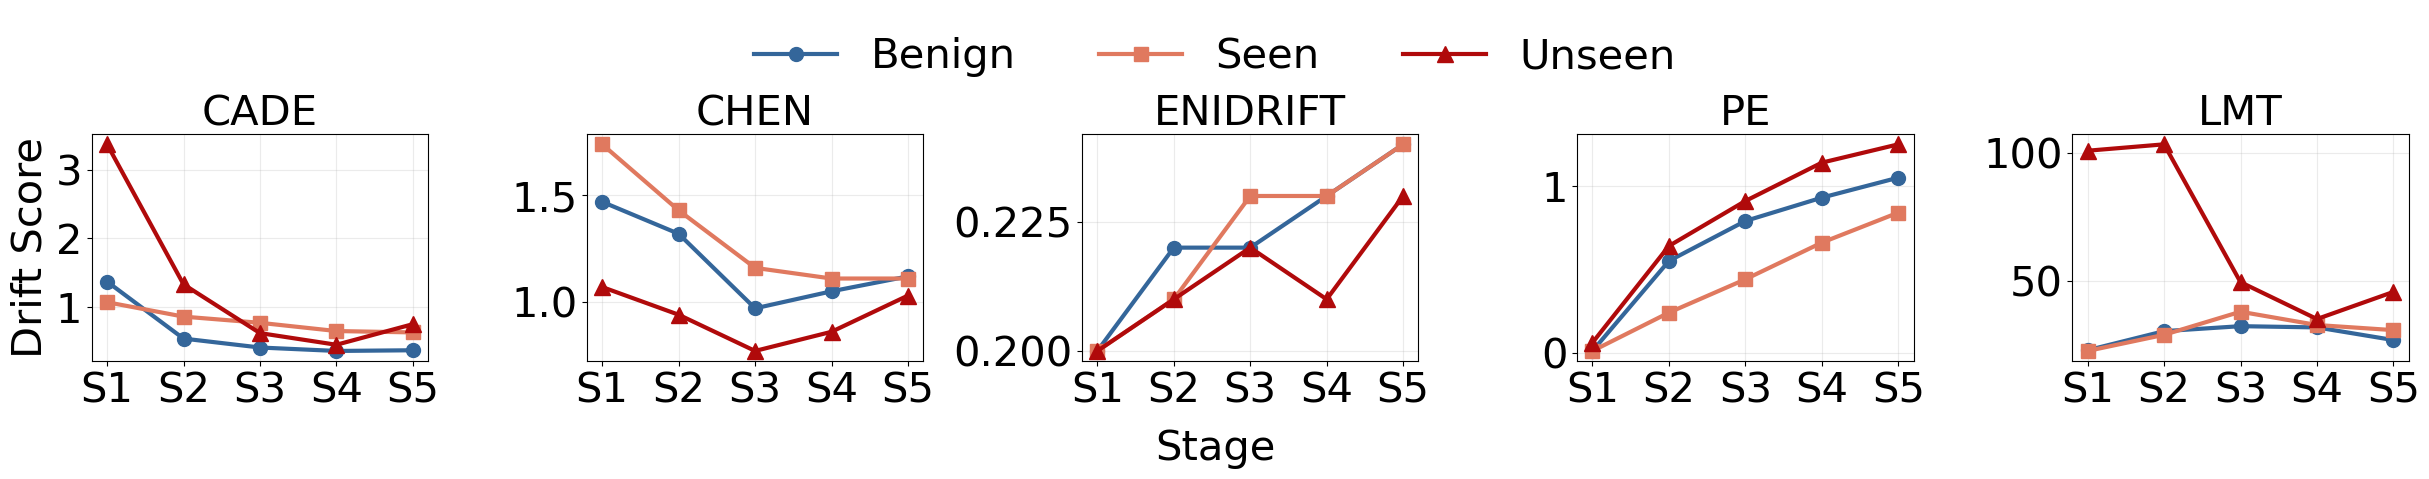

   Stage_ID                       Stage
0         1  S1 = Benign + Attack(1..1)
1         2  S2 = Benign + Attack(1..2)
2         3  S3 = Benign + Attack(1..3)
3         4  S4 = Benign + Attack(1..4)
4         5  S5 = Benign + Attack(1..5)


In [20]:
stage_map = plot_conditional_subplots(
    table_long,
    save_path="figs/ciciot23.pdf",
)
print(stage_map)